# Practical Application III: Comparing Classifiers

**Dataset:** Bank Marketing data from the UCI Machine Learning Repository  
**Models compared:** k-nearest neighbors, logistic regression, decision tree, and support vector machine  
**Target:** whether a contacted client subscribed to a term deposit (`y`)

This notebook follows the CRISP-DM workflow: business understanding, data understanding, preparation, modeling, evaluation, and recommendations.

## Executive Summary

The bank wants to increase term deposit subscriptions while reducing the cost of broad telephone campaigns. Because only a minority of contacted customers subscribe, the best model is not the one with the highest raw accuracy; it is the one that best finds likely subscribers without overwhelming staff with low-quality leads.

The analysis below uses **average precision** as the primary tuning metric because it evaluates ranking quality for the positive class in an imbalanced classification problem. I also report recall, precision, F1, ROC-AUC, and confusion matrices so the business tradeoffs are visible.

**Important modeling note:** `duration` is excluded from predictive modeling because it is only known after a call is completed. It is useful diagnostically, but using it for pre-call targeting would create data leakage.

## 1. Business Understanding

The business objective is to identify customers who are more likely to subscribe to a bank term deposit before or during campaign planning. Better targeting can help the bank prioritize higher-probability contacts, reduce wasted calls, and improve conversion rates.

This is a binary classification problem: predict whether `y = yes` for term deposit subscription. Since missed subscribers represent lost revenue opportunities, and the positive class is relatively rare, the modeling process emphasizes ranking and positive-class performance rather than accuracy alone.

In [1]:
# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Modeling
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.3f}'.format)
RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


## 2. Data Understanding

The data contains 41,188 records from Portuguese bank marketing campaigns. Each row represents a client contact and includes demographic, contact, campaign history, and broader economic features. The target variable is `y`, indicating whether the client subscribed to a term deposit.

In [2]:
data_path = Path('data/bank-additional-full.csv')
if not data_path.exists():
    data_path = Path('data/bank-additional/bank-additional-full.csv')

bank = pd.read_csv(data_path, sep=';')
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",no


In [3]:
print(f'Rows: {bank.shape[0]:,}')
print(f'Columns: {bank.shape[1]:,}')
display(bank.dtypes.to_frame('dtype').T)

Rows: 41,188
Columns: 21


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
dtype,int64,str,str,str,str,str,str,str,str,str,int64,int64,int64,int64,str,float64,float64,float64,float64,float64,str


In [4]:
missing_summary = pd.DataFrame({
    'missing_count': bank.isna().sum(),
    'missing_percent': bank.isna().mean() * 100,
    'unknown_count': (bank == 'unknown').sum(numeric_only=False),
    'unknown_percent': (bank == 'unknown').mean(numeric_only=False) * 100,
}).sort_values(['missing_percent', 'unknown_percent'], ascending=False)

missing_summary.query('missing_count > 0 or unknown_count > 0')

,missing_count,missing_percent,unknown_count,unknown_percent
default,0,0.000,8597,20.873
education,0,0.000,1731,4.203
housing,0,0.000,990,2.404
loan,0,0.000,990,2.404
job,0,0.000,330,0.801
marital,0,0.000,80,0.194


There are no true null values in the CSV, but several categorical fields use `unknown` as an explicit category. I keep `unknown` rather than dropping rows because the fact that information is missing may itself be predictive, and dropping those rows would remove useful campaign records.

In [5]:
target_distribution = bank['y'].value_counts().rename_axis('subscription').reset_index(name='count')
target_distribution['percent'] = target_distribution['count'] / len(bank) * 100
target_distribution

,subscription,count,percent
0,no,36548,88.735
1,yes,4640,11.265


The target is imbalanced: most contacted clients did **not** subscribe. This makes accuracy a weak standalone metric because a model can appear accurate by predicting mostly `no`.

## 3. Descriptive Statistics and Visual Exploration

In [6]:
numeric_features = bank.select_dtypes(include='number').columns.tolist()
categorical_features = bank.select_dtypes(include='object').drop(columns='y').columns.tolist()

bank[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,"41,188.000",40.024,10.421,17.000,32.000,38.000,47.000,98.000
duration,"41,188.000",258.285,259.279,0.000,102.000,180.000,319.000,"4,918.000"
campaign,"41,188.000",2.568,2.770,1.000,1.000,2.000,3.000,56.000
pdays,"41,188.000",962.475,186.911,0.000,999.000,999.000,999.000,999.000
previous,"41,188.000",0.173,0.495,0.000,0.000,0.000,0.000,7.000
emp.var.rate,"41,188.000",0.082,1.571,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,"41,188.000",93.576,0.579,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,"41,188.000",-40.503,4.628,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,"41,188.000",3.621,1.734,0.634,1.344,4.857,4.961,5.045
nr.employed,"41,188.000","5,167.036",72.252,"4,963.600","5,099.100","5,191.000","5,228.100","5,228.100"


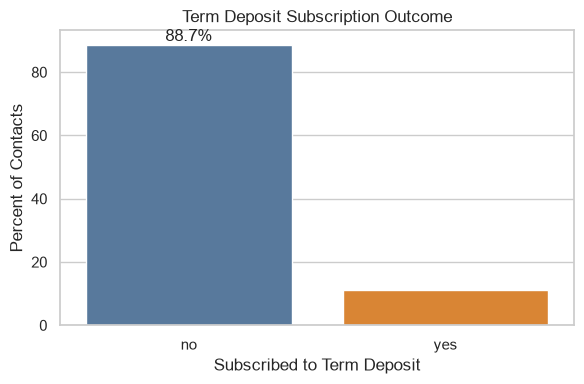

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=target_distribution, x='subscription', y='percent', ax=ax, palette=['#4C78A8', '#F58518'])
ax.set_title('Term Deposit Subscription Outcome')
ax.set_xlabel('Subscribed to Term Deposit')
ax.set_ylabel('Percent of Contacts')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.tight_layout()

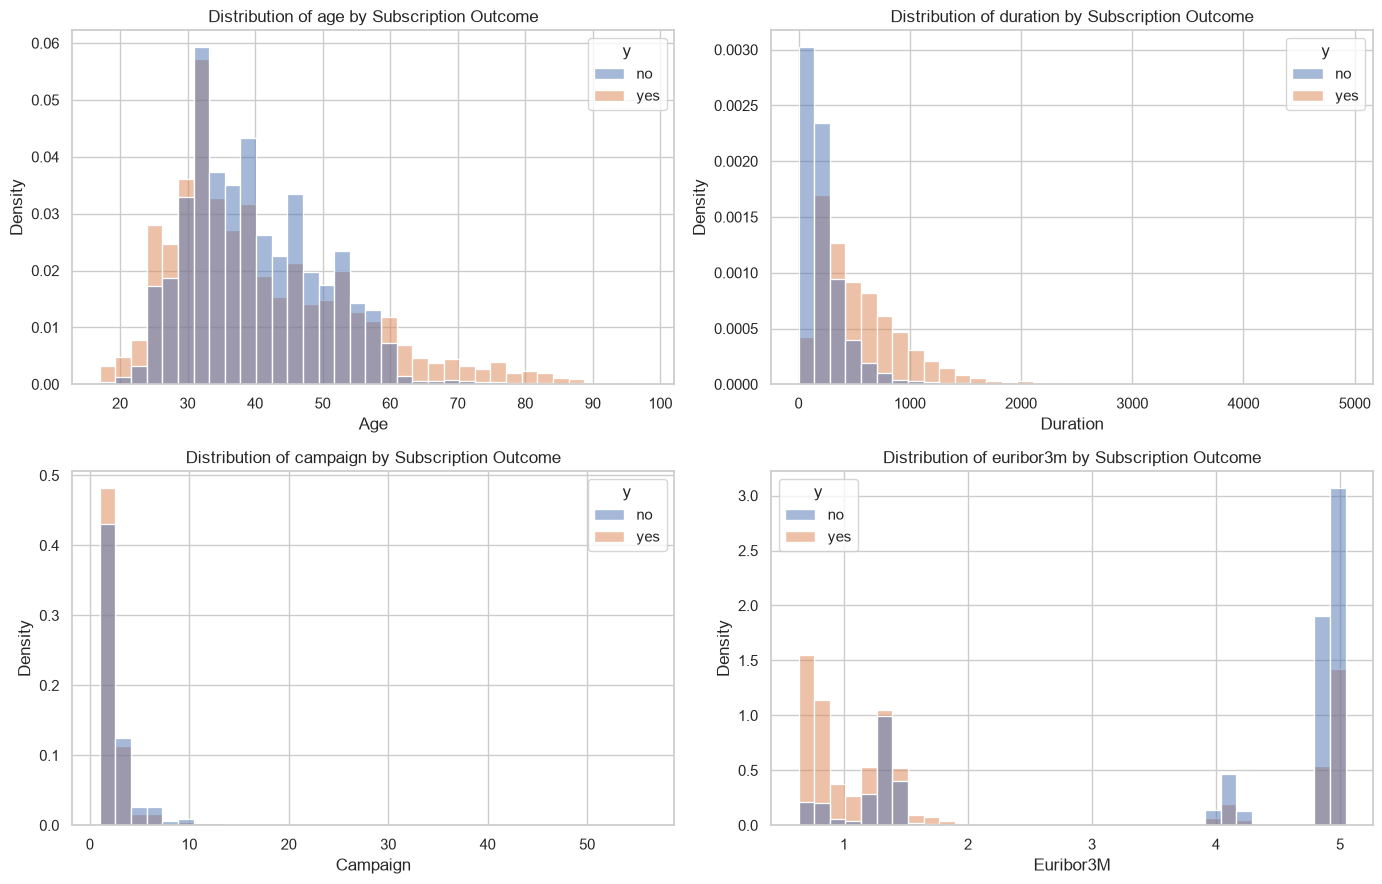

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
continuous_to_plot = ['age', 'duration', 'campaign', 'euribor3m']
for ax, feature in zip(axes.ravel(), continuous_to_plot):
    sns.histplot(data=bank, x=feature, hue='y', bins=35, stat='density', common_norm=False, ax=ax)
    ax.set_title(f'Distribution of {feature} by Subscription Outcome')
    ax.set_xlabel(feature.replace('.', ' ').title())
    ax.set_ylabel('Density')
plt.tight_layout()

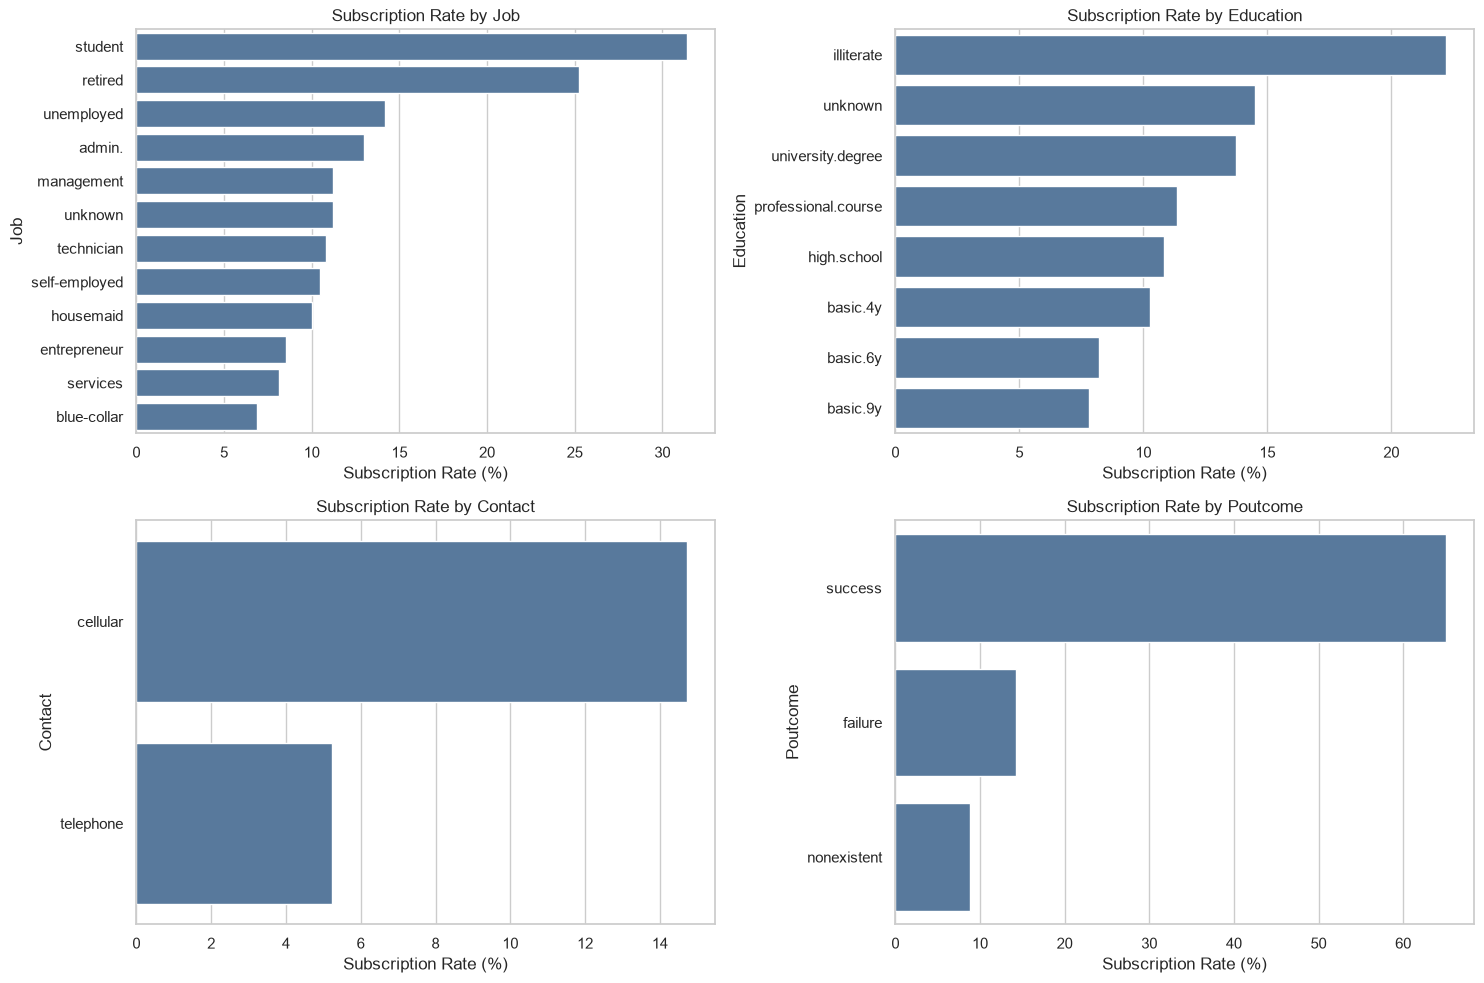

In [9]:
def subscription_rate_by(feature, top_n=None):
    summary = (
        bank.groupby(feature)['y']
        .apply(lambda values: (values == 'yes').mean())
        .mul(100)
        .reset_index(name='subscription_rate')
        .sort_values('subscription_rate', ascending=False)
    )
    if top_n:
        summary = summary.head(top_n)
    return summary

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, feature in zip(axes.ravel(), ['job', 'education', 'contact', 'poutcome']):
    plot_data = subscription_rate_by(feature)
    sns.barplot(data=plot_data, y=feature, x='subscription_rate', ax=ax, color='#4C78A8')
    ax.set_title(f'Subscription Rate by {feature.title()}')
    ax.set_xlabel('Subscription Rate (%)')
    ax.set_ylabel(feature.title())
plt.tight_layout()

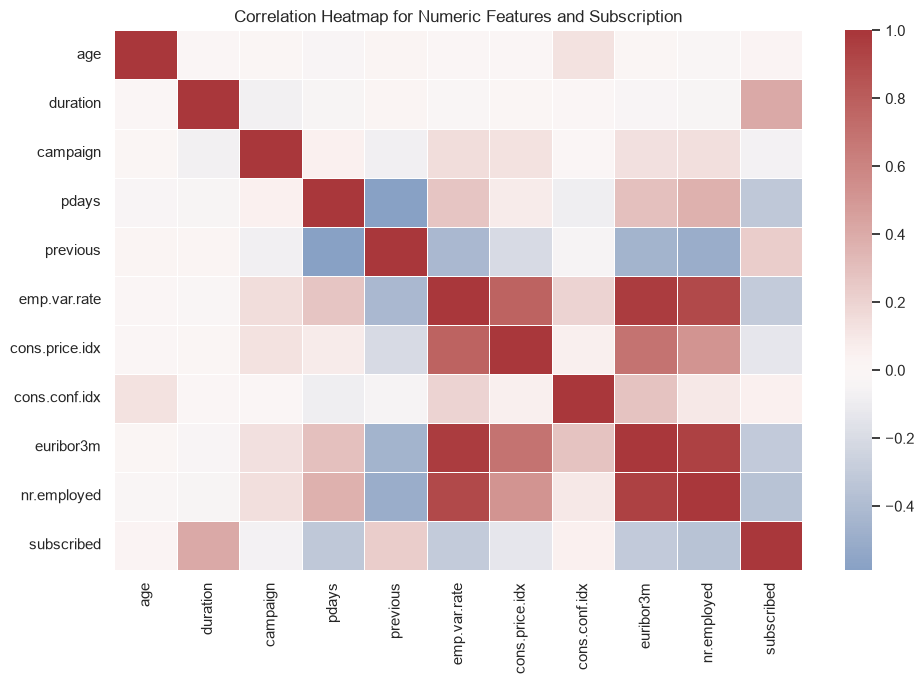

In [10]:
corr_data = bank[numeric_features].copy()
corr_data['subscribed'] = (bank['y'] == 'yes').astype(int)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_data.corr(), cmap='vlag', center=0, annot=False, linewidths=0.5)
plt.title('Correlation Heatmap for Numeric Features and Subscription')
plt.tight_layout()

### Descriptive Statistics Interpretation

Several patterns stand out:

- The subscription rate is low, so models must be evaluated with positive-class metrics.
- Prior campaign outcome (`poutcome`) is strongly associated with future subscription rates, especially when a previous campaign succeeded.
- Cellular contacts show higher subscription rates than telephone contacts.
- Economic context features such as `euribor3m`, `emp.var.rate`, and `nr.employed` move together and appear related to subscription outcomes.
- `duration` differs sharply by outcome, but it is excluded from predictive modeling because it is not known before the call.

## 4. Inferential Statistics

I use inferential tests to check whether key observed differences are unlikely to be due to random sampling variation. Because the dataset is large, p-values can become very small even for modest effects, so I interpret statistical significance together with business meaning.

In [11]:
def chi_square_test(feature):
    table = pd.crosstab(bank[feature], bank['y'])
    chi2, p_value, dof, expected = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    return {'feature': feature, 'chi2': chi2, 'p_value': p_value, 'cramers_v': cramers_v}

chi_square_results = pd.DataFrame([chi_square_test(feature) for feature in ['job', 'education', 'contact', 'poutcome', 'month']])
chi_square_results.sort_values('cramers_v', ascending=False)

,feature,chi2,p_value,cramers_v
3,poutcome,"4,230.524",0.000,0.320
4,month,"3,101.149",0.000,0.274
0,job,961.242,0.000,0.153
2,contact,862.318,0.000,0.145
1,education,193.106,0.000,0.068


In [12]:
yes_age = bank.loc[bank['y'] == 'yes', 'age']
no_age = bank.loc[bank['y'] == 'no', 'age']
mann_age = stats.mannwhitneyu(yes_age, no_age, alternative='two-sided')

yes_euribor = bank.loc[bank['y'] == 'yes', 'euribor3m']
no_euribor = bank.loc[bank['y'] == 'no', 'euribor3m']
mann_euribor = stats.mannwhitneyu(yes_euribor, no_euribor, alternative='two-sided')

inferential_numeric = pd.DataFrame([
    {'feature': 'age', 'yes_median': yes_age.median(), 'no_median': no_age.median(), 'p_value': mann_age.pvalue},
    {'feature': 'euribor3m', 'yes_median': yes_euribor.median(), 'no_median': no_euribor.median(), 'p_value': mann_euribor.pvalue},
])
inferential_numeric

,feature,yes_median,no_median,p_value
0,age,37.000,38.000,0.016
1,euribor3m,1.266,4.857,0.000


### Inferential Statistics Interpretation

The chi-square tests suggest that `poutcome`, `contact`, `month`, `job`, and `education` are statistically associated with subscription outcome. The largest association among these is prior campaign outcome, which is also intuitive: customers who previously responded positively are more likely to respond again.

The Mann-Whitney tests show statistically significant differences in age and euribor rate distributions between subscribers and non-subscribers. The euribor difference is more useful operationally because it reflects campaign timing and market conditions rather than only customer demographics.

## 5. Data Preparation

The preparation steps are designed for fair model comparison:

- Convert the target to binary values.
- Exclude `duration` to avoid leakage.
- Use one-hot encoding for categorical variables.
- Standardize numeric variables for distance-based and margin-based models.
- Use a stratified train/test split to preserve class balance.
- Tune models on a stratified training sample for practical runtime, then evaluate each best estimator on the same held-out test set.

In [13]:
model_data = bank.copy()
model_data['subscribed'] = (model_data['y'] == 'yes').astype(int)

leakage_columns = ['duration', 'y', 'subscribed']
X = model_data.drop(columns=leakage_columns)
y = model_data['subscribed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

train_sample_size = min(12000, len(X_train))
train_sample = X_train.assign(subscribed=y_train).groupby('subscribed', group_keys=False).sample(
    frac=train_sample_size / len(X_train), random_state=RANDOM_STATE
)
X_train_sample = train_sample.drop(columns='subscribed')
y_train_sample = train_sample['subscribed']

print(f'Training rows: {len(X_train):,}')
print(f'Tuning sample rows: {len(X_train_sample):,}')
print(f'Test rows: {len(X_test):,}')
print(f'Test positive rate: {y_test.mean():.3f}')

Training rows: 32,950
Tuning sample rows: 12,000
Test rows: 8,238
Test positive rate: 0.113


In [14]:
numeric_model_features = X.select_dtypes(include='number').columns.tolist()
categorical_model_features = X.select_dtypes(include='object').columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
])

preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_transformer, numeric_model_features),
    ('categorical', categorical_transformer, categorical_model_features),
])

## 6. Baseline Model

A baseline model establishes the minimum performance the classifiers should beat. The dummy classifier predicts the majority class and illustrates why accuracy alone can be misleading.

In [15]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_predictions = baseline.predict(X_test)

baseline_results = pd.DataFrame([{
    'model': 'Baseline: majority class',
    'accuracy': accuracy_score(y_test, baseline_predictions),
    'precision': precision_score(y_test, baseline_predictions, zero_division=0),
    'recall': recall_score(y_test, baseline_predictions, zero_division=0),
    'f1': f1_score(y_test, baseline_predictions, zero_division=0),
}])
baseline_results

,model,accuracy,precision,recall,f1
0,Baseline: majority class,0.887,0.000,0.000,0.000


The baseline has high-looking accuracy because most clients do not subscribe, but it has zero recall for subscribers. A useful model must beat this by identifying at least some likely subscribers.

## 7. Model Training and Cross-Validation

The four required classifiers are compared with the same preprocessing and stratified cross-validation. I tune hyperparameters with `GridSearchCV` using **average precision** as the scoring metric because the business needs a ranked list of likely subscribers from an imbalanced population.

In [16]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

model_grids = {
    'Logistic Regression': {
        'pipeline': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear', random_state=RANDOM_STATE)),
        ]),
        'params': {'model__C': [0.1, 1, 10]},
    },
    'K-Nearest Neighbors': {
        'pipeline': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', KNeighborsClassifier()),
        ]),
        'params': {'model__n_neighbors': [5, 15, 31], 'model__weights': ['uniform', 'distance']},
    },
    'Decision Tree': {
        'pipeline': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)),
        ]),
        'params': {'model__max_depth': [4, 6, 10, None], 'model__min_samples_leaf': [25, 50, 100]},
    },
    'Support Vector Machine': {
        'pipeline': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=5000)),
        ]),
        'params': {'model__C': [0.1, 1, 10]},
    },
}

In [17]:
def positive_scores(estimator, X_values):
    if hasattr(estimator, 'predict_proba'):
        return estimator.predict_proba(X_values)[:, 1]
    return estimator.decision_function(X_values)

searches = {}
model_rows = []

for model_name, config in model_grids.items():
    search = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['params'],
        scoring='average_precision',
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train_sample, y_train_sample)
    searches[model_name] = search

    predictions = search.predict(X_test)
    scores = positive_scores(search.best_estimator_, X_test)

    model_rows.append({
        'model': model_name,
        'best_params': search.best_params_,
        'cv_average_precision': search.best_score_,
        'test_average_precision': average_precision_score(y_test, scores),
        'test_roc_auc': roc_auc_score(y_test, scores),
        'test_accuracy': accuracy_score(y_test, predictions),
        'test_precision': precision_score(y_test, predictions, zero_division=0),
        'test_recall': recall_score(y_test, predictions, zero_division=0),
        'test_f1': f1_score(y_test, predictions, zero_division=0),
    })

results = pd.DataFrame(model_rows).sort_values('test_average_precision', ascending=False)
results

,model,best_params,cv_average_precision,test_average_precision,test_roc_auc,test_accuracy,test_precision,test_recall,test_f1
0,Logistic Regression,{'model__C': 1},0.437,0.453,0.798,0.830,0.358,0.649,0.462
3,Support Vector Machine,{'model__C': 10},0.431,0.447,0.799,0.831,0.360,0.647,0.462
1,K-Nearest Neighbors,"{'model__n_neighbors': 31, 'model__weights': '...",0.409,0.436,0.786,0.902,0.683,0.237,0.352
2,Decision Tree,"{'model__max_depth': 10, 'model__min_samples_l...",0.408,0.435,0.790,0.808,0.327,0.664,0.438


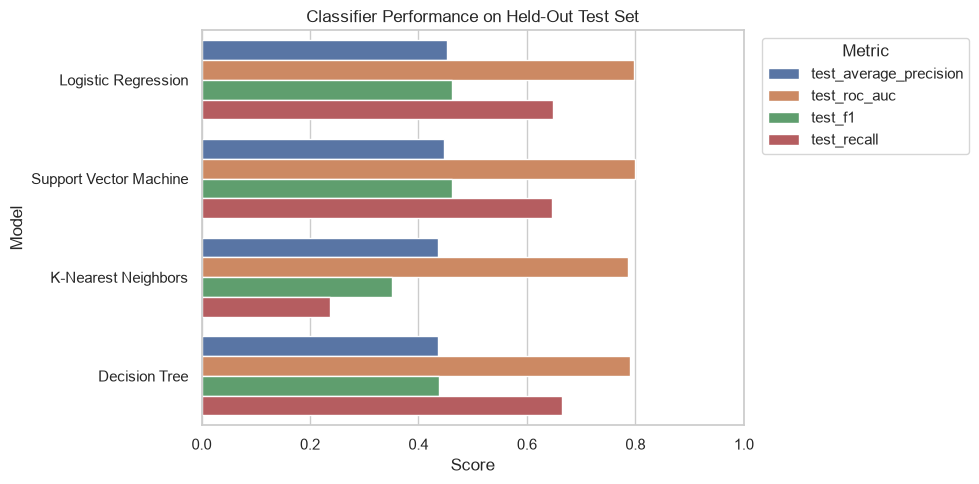

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_results = results.melt(
    id_vars='model',
    value_vars=['test_average_precision', 'test_roc_auc', 'test_f1', 'test_recall'],
    var_name='metric',
    value_name='score',
)
sns.barplot(data=plot_results, x='score', y='model', hue='metric', ax=ax)
ax.set_title('Classifier Performance on Held-Out Test Set')
ax.set_xlabel('Score')
ax.set_ylabel('Model')
ax.set_xlim(0, 1)
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

              precision    recall  f1-score   support

          No       0.95      0.85      0.90      7310
         Yes       0.36      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238



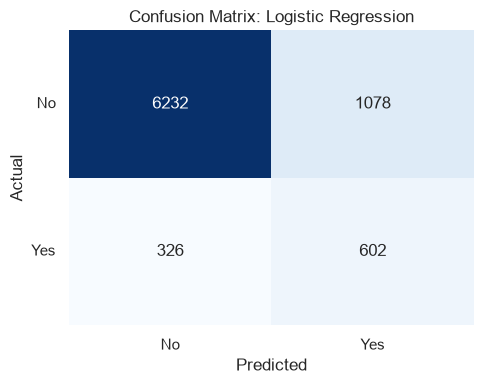

In [19]:
best_model_name = results.iloc[0]['model']
best_model = searches[best_model_name].best_estimator_
best_predictions = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_predictions)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title(f'Confusion Matrix: {best_model_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticklabels(['No', 'Yes'])
ax.set_yticklabels(['No', 'Yes'], rotation=0)
plt.tight_layout()

print(classification_report(y_test, best_predictions, target_names=['No', 'Yes']))

## 8. Logistic Regression Coefficient Interpretation

Logistic regression is especially useful because its coefficients can be interpreted as directional effects after preprocessing. Positive coefficients increase the log-odds of subscription; negative coefficients decrease them. Because features are scaled and one-hot encoded, the table is best interpreted as a ranked signal list rather than a causal estimate.

In [20]:
logistic_model = searches['Logistic Regression'].best_estimator_
feature_names = logistic_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = logistic_model.named_steps['model'].coef_[0]

coef_table = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'odds_ratio': np.exp(coefficients),
})

top_positive = coef_table.sort_values('coefficient', ascending=False).head(10)
top_negative = coef_table.sort_values('coefficient').head(10)

pd.concat([
    top_positive.assign(direction='Higher subscription likelihood'),
    top_negative.assign(direction='Lower subscription likelihood'),
]).reset_index(drop=True)

,feature,coefficient,odds_ratio,direction
0,categorical__month_mar,1.212,3.360,Higher subscription likelihood
1,numeric__cons.price.idx,1.185,3.269,Higher subscription likelihood
2,categorical__month_dec,0.953,2.592,Higher subscription likelihood
3,categorical__job_unknown,0.586,1.796,Higher subscription likelihood
4,numeric__nr.employed,0.469,1.599,Higher subscription likelihood
5,numeric__euribor3m,0.420,1.522,Higher subscription likelihood
6,categorical__month_aug,0.411,1.508,Higher subscription likelihood
7,categorical__poutcome_success,0.402,1.495,Higher subscription likelihood
8,categorical__marital_unknown,0.382,1.465,Higher subscription likelihood
9,categorical__job_retired,0.369,1.446,Higher subscription likelihood


### Coefficient Interpretation

The strongest positive coefficients identify characteristics associated with a higher likelihood of subscription after accounting for the other model inputs. The strongest negative coefficients identify lower-probability groups or conditions. These coefficients support practical campaign segmentation, but they should not be treated as proof that changing a single feature would cause a customer to subscribe.

## 9. Findings and Recommendations

### Key Findings

1. **The campaign response is highly imbalanced.** Only a small share of contacts subscribe, so raw accuracy is not enough for evaluation.
2. **Prior response matters.** Customers with a successful previous campaign outcome are much more promising than customers with no prior positive response.
3. **Contact channel matters.** Cellular contacts tend to convert better than telephone contacts.
4. **Market context matters.** Economic variables such as euribor rate and employment indicators are predictive and should be considered when planning campaigns.
5. **Model choice should reflect business capacity.** If call-center capacity is limited, prioritize a model with stronger average precision so agents receive a better-ranked lead list. If the bank wants to contact as many potential subscribers as possible, recall becomes more important.

### Actionable Recommendations

- **Prioritize high-scoring customers** from the selected model rather than calling the full customer list uniformly.
- **Create a campaign tiering process:** highest-score customers receive immediate agent outreach; medium-score customers receive lower-cost follow-up; low-score customers are deferred or contacted through cheaper channels.
- **Use previous campaign outcome and contact channel in segmentation.** These variables are interpretable and actionable for campaign planning.
- **Do not use call duration for pre-call targeting.** It is a useful post-call diagnostic, but including it in pre-call predictions would overstate model performance.
- **Track precision and recall by campaign wave.** Business conditions change, so model performance should be monitored over time.

## 10. Next Steps

1. Validate the selected model on a later time period because the original data is ordered by campaign date.
2. Choose an operating threshold based on available agent capacity and the expected profit from a successful term deposit.
3. Add campaign cost and customer value data to optimize for expected profit, not just classification metrics.
4. Test calibrated probabilities so managers can interpret model scores as estimated likelihoods.
5. Run a controlled pilot campaign comparing model-ranked outreach against the current targeting process.

## Appendix: Reproducibility Notes

- Source data: UCI Bank Marketing dataset, `bank-additional-full.csv`.
- Citation: Moro, Cortez, and Rita (2014), *A Data-Driven Approach to Predict the Success of Bank Telemarketing*.
- Random seed: 42.
- Primary metric: average precision, selected because the positive class is rare and the bank needs ranked leads for campaign targeting.